#  Klasifikasi Makanan Indonesia dengan CNN

**Dataset:** [Indonesian Food Dataset (rizkyyk/dataset-food-classification)](https://www.kaggle.com/datasets/rizkyyk/dataset-food-classification)

Notebook ini membangun model **Convolutional Neural Network (CNN)** untuk mengklasifikasikan
gambar makanan khas Indonesia. Alur kerja (pipeline) yang dijalankan:

1. **Setup** — instalasi dependensi & pembuatan struktur folder proyek.
2. **Akuisisi Data** — mengunduh dataset langsung dari Kaggle melalui Kaggle API.
3. **Eksplorasi Data (EDA)** — memeriksa struktur folder, distribusi kelas, dan sampel gambar.
4. **Data Pipeline** — memuat gambar menjadi `tf.data.Dataset` (train / validation / test).
5. **Pemodelan** — membangun arsitektur CNN dengan augmentasi data bawaan.
6. **Training** — melatih model dengan callback (checkpoint, early stopping, reduce LR).
7. **Evaluasi** — kurva training, classification report, dan confusion matrix.
8. **Penyimpanan** — menyimpan model final + metadata kelas untuk dipakai aplikasi UI deteksi.

**Struktur folder proyek** (dibuat otomatis oleh notebook):

```text
CNN_FOOD_INDONESIAN/
├── training_cnn_food_indonesian.ipynb   <- notebook ini
├── dataset/                             <- dataset hasil unduhan dari Kaggle
├── models/                              <- model terlatih (.keras) + metadata kelas
├── outputs/                             <- grafik training, confusion matrix, dll.
└── app/
    └── food_detector_app.py             <- aplikasi UI deteksi (Tkinter)
```

## 1. Instalasi Dependensi

Sel ini menginstal seluruh library yang dibutuhkan:

- `tensorflow` — framework deep learning untuk membangun & melatih CNN.
- `kaggle` — Kaggle API resmi untuk mengunduh dataset secara programatik.
- `numpy`, `matplotlib` — komputasi numerik & visualisasi.
- `scikit-learn` — classification report & confusion matrix.
- `pillow` — pemrosesan gambar.

> Jika semua sudah terinstal, sel ini aman dijalankan ulang (pip akan melewati paket yang sudah ada).

In [1]:
# ============================================================
# 1. INSTALASI DEPENDENSI
# ------------------------------------------------------------
# Menginstal seluruh library yang dibutuhkan notebook ini.
# Flag -q (quiet) dipakai agar output instalasi tidak terlalu
# panjang memenuhi layar.
# ============================================================
%pip install -q tensorflow kaggle numpy matplotlib scikit-learn pillow

print(' Instalasi dependensi selesai.')

Note: you may need to restart the kernel to use updated packages.
 Instalasi dependensi selesai.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Library & Pengecekan Environment

Sel ini mengimpor seluruh library, mengunci *random seed* agar hasil eksperimen
**reproducible** (dapat diulang dengan hasil sama), dan menampilkan informasi
environment: versi TensorFlow serta ketersediaan GPU.
Jika GPU terdeteksi, training otomatis berjalan jauh lebih cepat.

In [2]:
# ============================================================
# 2. IMPORT LIBRARY & PENGECEKAN ENVIRONMENT
# ============================================================
import os
import json
import random
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Mengunci random seed agar eksperimen reproducible -------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Informasi environment -----------------------------------
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'Versi TensorFlow : {tf.__version__}')
print(f'GPU terdeteksi   : {gpu_devices if gpu_devices else "Tidak ada (training memakai CPU)"}')

c:\Users\alyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Versi TensorFlow : 2.20.0
GPU terdeteksi   : Tidak ada (training memakai CPU)


## 3. Konfigurasi Global & Pembuatan Struktur Folder

Sel ini mendefinisikan **seluruh parameter penting di satu tempat** (path folder,
ukuran gambar, batch size, jumlah epoch, learning rate) sehingga mudah diubah
tanpa menyentuh kode lain. Folder `dataset/`, `models/`, `outputs/`, dan `app/`
dibuat otomatis jika belum ada agar struktur proyek selalu rapi.

In [3]:
# ============================================================
# 3. KONFIGURASI GLOBAL & STRUKTUR FOLDER
# ============================================================

# --- Identitas dataset di Kaggle ------------------------------
KAGGLE_DATASET = 'rizkyyk/dataset-food-classification'

# --- Struktur folder proyek -----------------------------------
BASE_DIR    = Path.cwd()                  # folder kerja proyek
DATASET_DIR = BASE_DIR / 'dataset'        # tempat dataset hasil unduhan
MODELS_DIR  = BASE_DIR / 'models'         # tempat model terlatih + metadata
OUTPUTS_DIR = BASE_DIR / 'outputs'        # tempat grafik & artefak evaluasi
APP_DIR     = BASE_DIR / 'app'            # tempat aplikasi UI deteksi

# Membuat semua folder (parents=True & exist_ok=True -> aman dijalankan ulang)
for folder in (DATASET_DIR, MODELS_DIR, OUTPUTS_DIR, APP_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# --- Hyperparameter training ----------------------------------
IMG_SIZE      = (224, 224)   # ukuran input gambar (lebar x tinggi)
BATCH_SIZE    = 32           # jumlah gambar per batch
EPOCHS_HEAD        = 12      # melatih classifier head saat backbone dibekukan
EPOCHS_FINE_TUNE   = 12      # fine-tuning sebagian backbone pretrained
LEARNING_RATE      = 1e-3    # learning rate classifier head
FINE_TUNE_LR       = 1e-5    # learning rate kecil agar fitur pretrained tidak rusak
VAL_SPLIT     = 0.2          # porsi data validasi jika dataset tidak punya split bawaan

# --- Nama file artefak yang dihasilkan ------------------------
BEST_MODEL_PATH  = MODELS_DIR / 'cnn_food_indonesian_best.keras'   # model dengan validasi terbaik
HEAD_MODEL_PATH  = MODELS_DIR / 'cnn_food_indonesian_head.keras'   # checkpoint tahap classifier head
FINE_MODEL_PATH  = MODELS_DIR / 'cnn_food_indonesian_finetuned.keras' # checkpoint tahap fine-tuning
FINAL_MODEL_PATH = MODELS_DIR / 'cnn_food_indonesian_final.keras'  # model akhir
CLASS_NAMES_PATH = MODELS_DIR / 'class_names.json'                 # daftar nama kelas
METADATA_PATH    = MODELS_DIR / 'model_metadata.json'              # metadata model (untuk UI)

print('Struktur folder proyek siap:')
for folder in (DATASET_DIR, MODELS_DIR, OUTPUTS_DIR, APP_DIR):
    print(f'   {folder}')

Struktur folder proyek siap:
   c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset
   c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\models
   c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\outputs
   c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\app


## 4. Download Dataset dari Kaggle (Kaggle API)

Sel ini mengunduh dataset **langsung dari Kaggle** menggunakan Kaggle API resmi,
lalu mengekstraknya ke folder `dataset/`.

**Syarat: kredensial Kaggle (`kaggle.json`)** harus tersedia. Cara mendapatkannya:

1. Login ke [kaggle.com](https://www.kaggle.com) → klik foto profil → **Settings**.
2. Pada bagian **API**, klik **Create New Token** → file `kaggle.json` akan terunduh.
3. Letakkan file tersebut di:
   - **Windows:** `C:\Users\<nama_user>\.kaggle\kaggle.json`
   - **Linux/Mac:** `~/.kaggle/kaggle.json`

Sel ini juga **idempoten**: jika dataset sudah pernah diunduh, proses unduh dilewati
sehingga aman dijalankan berulang kali.

In [4]:
# ============================================================
# 4. DOWNLOAD DATASET DARI KAGGLE
# ============================================================

def cek_kredensial_kaggle():
    """Memastikan kredensial Kaggle (kaggle.json / env var) tersedia.

    Kaggle API mencari kredensial di file ~/.kaggle/kaggle.json atau
    environment variable KAGGLE_USERNAME & KAGGLE_KEY. Jika keduanya
    tidak ada, fungsi ini menghentikan eksekusi dengan pesan panduan.
    """
    kaggle_json = Path.home() / '.kaggle' / 'kaggle.json'
    env_tersedia = 'KAGGLE_USERNAME' in os.environ and 'KAGGLE_KEY' in os.environ

    if not kaggle_json.exists() and not env_tersedia:
        raise FileNotFoundError(
            f'Kredensial Kaggle tidak ditemukan!\n'
            f'Letakkan kaggle.json di: {kaggle_json}\n'
            f'(Unduh token dari kaggle.com -> Settings -> API -> Create New Token)'
        )
    print(' Kredensial Kaggle ditemukan.')


def download_dataset():
    """Mengunduh & mengekstrak dataset dari Kaggle ke folder dataset/.

    Jika folder dataset/ sudah berisi file (sudah pernah diunduh),
    proses unduh dilewati agar tidak membuang waktu & kuota.
    """
    # Cek apakah dataset sudah ada (folder tidak kosong)
    if any(DATASET_DIR.iterdir()):
        print(f'ℹ  Dataset sudah ada di {DATASET_DIR} — proses unduh dilewati.')
        return

    cek_kredensial_kaggle()

    # Import diletakkan di sini karena KaggleApi langsung membaca
    # kredensial saat diimpor/diautentikasi
    from kaggle.api.kaggle_api_extended import KaggleApi

    api = KaggleApi()
    api.authenticate()

    print(f'⬇  Mengunduh dataset "{KAGGLE_DATASET}" ... (beberapa menit)')
    api.dataset_download_files(
        KAGGLE_DATASET,
        path=str(DATASET_DIR),  # simpan ke folder dataset/
        unzip=True,             # langsung ekstrak file zip
        quiet=False,
    )
    print(f' Dataset berhasil diunduh & diekstrak ke {DATASET_DIR}')


download_dataset()

ℹ  Dataset sudah ada di c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset — proses unduh dilewati.


## 5. Deteksi Struktur Dataset Secara Otomatis

Dataset di Kaggle bisa memiliki dua bentuk struktur folder:

1. **Sudah terbagi** — ada folder `train/`, `valid/`, `test/` yang masing-masing berisi folder kelas.
2. **Datar (flat)** — langsung berisi folder kelas (`bakso/`, `rendang/`, dst.) tanpa pembagian.

Sel ini **memindai folder `dataset/` secara rekursif** dan mendeteksi otomatis bentuk
mana yang dipakai, sehingga sel-sel berikutnya tidak perlu diubah manual apa pun
struktur datasetnya. Jika struktur datar, pembagian train/validation dilakukan
otomatis di langkah pembuatan data pipeline.

In [5]:
# ============================================================
# 5. DETEKSI STRUKTUR DATASET
# ============================================================

# Ekstensi file yang dianggap sebagai gambar
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

# Alias nama folder split yang umum dipakai di berbagai dataset
SPLIT_ALIASES = {
    'train': {'train', 'training'},
    'valid': {'valid', 'validation', 'val'},
    'test':  {'test', 'testing'},
}


def berisi_gambar(folder: Path) -> bool:
    """True jika folder berisi minimal satu file gambar (cek langsung, non-rekursif)."""
    return any(f.suffix.lower() in IMG_EXTS for f in folder.iterdir() if f.is_file())


def adalah_folder_kelas(folder: Path) -> bool:
    """True jika folder berisi sub-folder kelas yang masing-masing berisi gambar.

    Contoh: dataset/train/ adalah folder kelas karena berisi
    train/bakso/*.jpg, train/rendang/*.jpg, dst.
    """
    subfolder = [d for d in folder.iterdir() if d.is_dir()]
    return len(subfolder) >= 2 and any(berisi_gambar(d) for d in subfolder)


def deteksi_struktur(root: Path):
    """Memindai folder dataset & mengembalikan path split yang ditemukan.

    Return:
        dict {'train': Path|None, 'valid': Path|None, 'test': Path|None}
        atau {'flat': Path} jika struktur datar (langsung folder kelas).
    """
    # --- Cari folder train/valid/test di seluruh hirarki -------
    hasil = {'train': None, 'valid': None, 'test': None}
    for folder in [root, *[d for d in root.rglob('*') if d.is_dir()]]:
        nama = folder.name.lower()
        for split, alias in SPLIT_ALIASES.items():
            if nama in alias and hasil[split] is None and adalah_folder_kelas(folder):
                hasil[split] = folder

    if hasil['train'] is not None:
        return hasil  # dataset sudah punya split bawaan

    # --- Tidak ada split: cari folder kelas datar ---------------
    for folder in [root, *[d for d in root.rglob('*') if d.is_dir()]]:
        if adalah_folder_kelas(folder):
            return {'flat': folder}

    raise RuntimeError(f'Tidak ditemukan struktur folder kelas di {root}')


# --- Jalankan deteksi & tampilkan hasilnya ---------------------
struktur = deteksi_struktur(DATASET_DIR)

if 'flat' in struktur:
    print(f' Struktur DATAR terdeteksi  : {struktur["flat"]}')
    print(f'   -> Split train/validation {int((1-VAL_SPLIT)*100)}/{int(VAL_SPLIT*100)} akan dibuat otomatis.')
else:
    for split, path in struktur.items():
        print(f' Folder {split:<6}: {path if path else "(tidak ada)"}')

 Folder train : c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset\dataset_gambar\train
 Folder valid : c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset\dataset_gambar\valid
 Folder test  : c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset\dataset_gambar\test


## 6. Eksplorasi Data: Distribusi Jumlah Gambar per Kelas

Sel ini menghitung jumlah gambar pada setiap kelas makanan dan menampilkannya
sebagai **bar chart**. Tujuannya untuk memeriksa apakah dataset **seimbang
(balanced)** — jika ada kelas yang jumlah gambarnya jauh lebih sedikit, model
berisiko bias terhadap kelas mayoritas. Grafik disimpan ke `outputs/distribusi_kelas.png`.

Jumlah kelas        : 13
Total gambar (acuan): 5199
  - Ayam Goreng              : 400 gambar
  - Burger                   : 400 gambar
  - French Fries             : 400 gambar
  - Gado-Gado                : 400 gambar
  - Ikan Goreng              : 400 gambar
  - Mie Goreng               : 399 gambar
  - Nasi Goreng              : 400 gambar
  - Nasi Padang              : 400 gambar
  - Pizza                    : 400 gambar
  - Rawon                    : 400 gambar
  - Rendang                  : 400 gambar
  - Sate                     : 400 gambar
  - Soto                     : 400 gambar


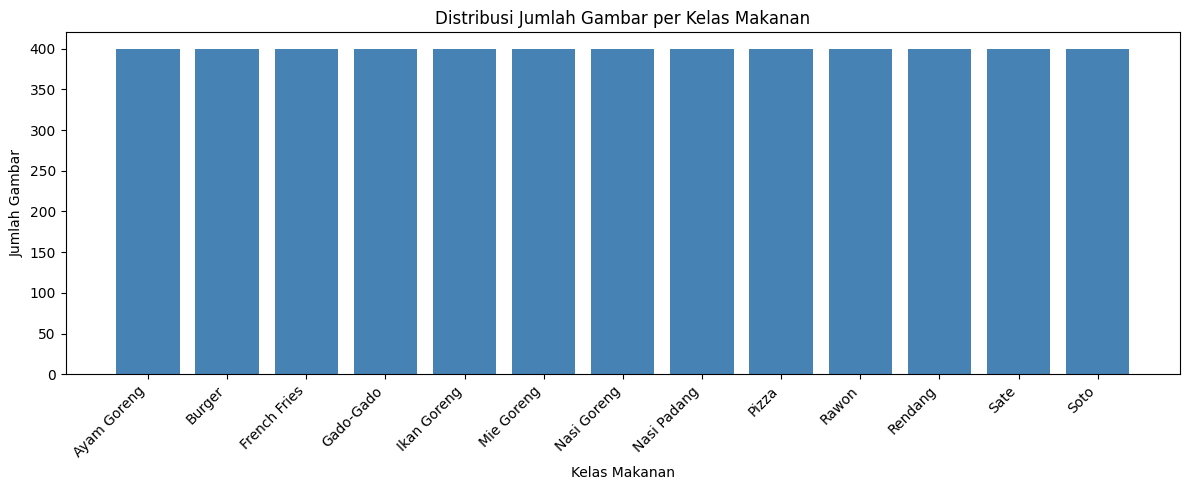

In [6]:
# ============================================================
# 6. DISTRIBUSI JUMLAH GAMBAR PER KELAS
# ============================================================

# Folder acuan untuk menghitung distribusi:
# pakai folder train jika ada split, atau folder datar jika tidak
FOLDER_ACUAN = struktur.get('train') or struktur.get('flat')

# Hitung jumlah gambar per folder kelas (diurutkan sesuai abjad)
distribusi = {}
for folder_kelas in sorted(d for d in FOLDER_ACUAN.iterdir() if d.is_dir()):
    jumlah = sum(1 for f in folder_kelas.rglob('*') if f.suffix.lower() in IMG_EXTS)
    distribusi[folder_kelas.name] = jumlah

print(f'Jumlah kelas        : {len(distribusi)}')
print(f'Total gambar (acuan): {sum(distribusi.values())}')
for nama, jumlah in distribusi.items():
    print(f'  - {nama:<25}: {jumlah} gambar')

# --- Visualisasi bar chart -------------------------------------
plt.figure(figsize=(12, 5))
plt.bar(distribusi.keys(), distribusi.values(), color='steelblue')
plt.title('Distribusi Jumlah Gambar per Kelas Makanan')
plt.xlabel('Kelas Makanan')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'distribusi_kelas.png', dpi=150)  # simpan ke outputs/
plt.show()

## 7. Visualisasi Sampel Gambar

Sel ini menampilkan **satu gambar contoh dari setiap kelas** dalam bentuk grid.
Langkah ini penting untuk memverifikasi secara visual bahwa gambar terbaca dengan
benar, label folder sesuai dengan isi gambarnya, dan kualitas gambar layak untuk training.

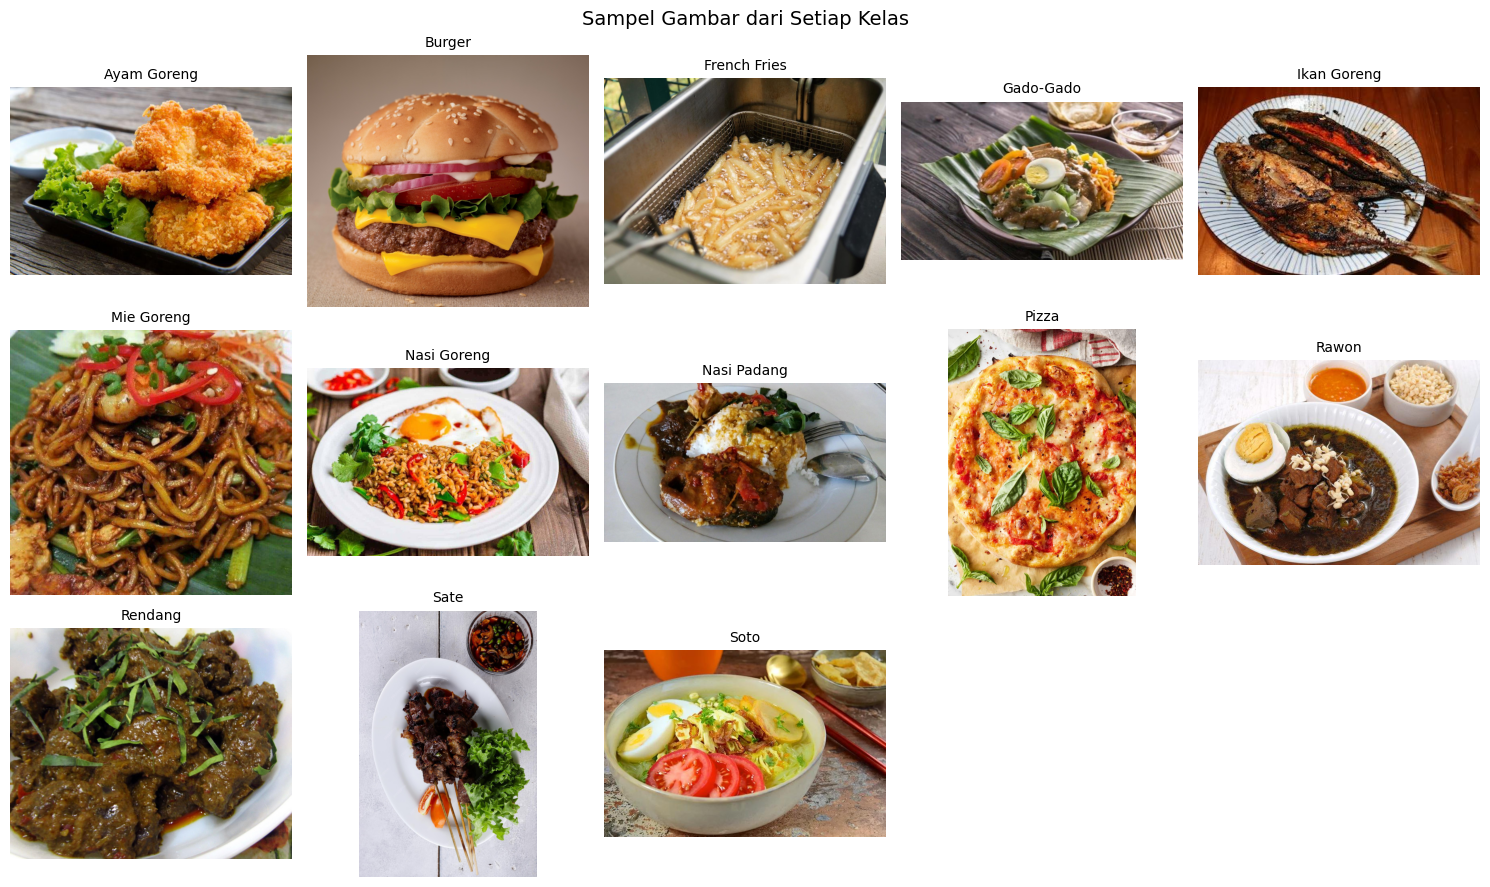

In [7]:
# ============================================================
# 7. VISUALISASI SAMPEL GAMBAR (1 GAMBAR PER KELAS)
# ============================================================
from PIL import Image

nama_kelas_eda = list(distribusi.keys())
n_kelas  = len(nama_kelas_eda)
n_kolom  = 5                                  # 5 gambar per baris
n_baris  = -(-n_kelas // n_kolom)             # pembulatan ke atas

plt.figure(figsize=(3 * n_kolom, 3 * n_baris))
for i, nama in enumerate(nama_kelas_eda):
    # Ambil satu file gambar pertama dari folder kelas
    folder_kelas = FOLDER_ACUAN / nama
    file_gambar  = next(f for f in folder_kelas.rglob('*') if f.suffix.lower() in IMG_EXTS)

    plt.subplot(n_baris, n_kolom, i + 1)
    plt.imshow(Image.open(file_gambar).convert('RGB'))
    plt.title(nama, fontsize=10)
    plt.axis('off')  # sembunyikan sumbu agar grid bersih

plt.suptitle('Sampel Gambar dari Setiap Kelas', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'sampel_gambar.png', dpi=150)
plt.show()

## 8. Data Pipeline: Memuat Dataset menjadi `tf.data.Dataset`

Sel ini memuat gambar dari folder menjadi objek `tf.data.Dataset` yang efisien:

- Gambar otomatis di-*resize* ke `IMG_SIZE` dan dikelompokkan per `BATCH_SIZE`.
- Label di-*encode* sebagai integer (sesuai urutan abjad nama folder kelas).
- `cache()` + `prefetch()` dipakai agar pembacaan data tidak menjadi *bottleneck* GPU.

Logika pembagian data menyesuaikan hasil deteksi struktur di langkah 5:

| Kondisi dataset | Train | Validation | Test |
|---|---|---|---|
| Punya `train/valid/test` | folder `train` | folder `valid` | folder `test` |
| Punya `train/test` saja | `train` (80%) | `train` (20%) | folder `test` |
| Datar (tanpa split) | 80% data | 10% data | 10% data |

In [8]:
# ============================================================
# 8. MEMBUAT DATA PIPELINE (train / validation / test)
# ============================================================

def muat_folder(folder, subset=None, val_split=None, shuffle=True):
    """Wrapper image_dataset_from_directory dengan parameter konsisten."""
    return keras.utils.image_dataset_from_directory(
        folder,
        labels='inferred',            # label diambil dari nama folder
        label_mode='int',             # label berupa integer (untuk sparse loss)
        image_size=IMG_SIZE,          # resize otomatis ke 224x224
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
        validation_split=val_split,   # None jika tidak membagi
        subset=subset,                # 'training' / 'validation' / None
    )


if 'flat' in struktur:
    # --- Struktur DATAR: bagi 80% train, 20% sisanya -----------
    train_ds = muat_folder(struktur['flat'], subset='training',   val_split=VAL_SPLIT)
    sisa_ds  = muat_folder(struktur['flat'], subset='validation', val_split=VAL_SPLIT)
    class_names = train_ds.class_names

    # Bagi dua porsi 20% tadi menjadi validation (10%) & test (10%)
    n_batch_sisa = tf.data.experimental.cardinality(sisa_ds).numpy()
    val_ds  = sisa_ds.take(n_batch_sisa // 2)
    test_ds = sisa_ds.skip(n_batch_sisa // 2)
else:
    # --- Struktur SPLIT: pakai folder bawaan dataset -----------
    if struktur['valid'] is not None:
        # Dataset punya folder validation sendiri
        train_ds = muat_folder(struktur['train'])
        val_ds   = muat_folder(struktur['valid'], shuffle=False)
    else:
        # Tidak ada folder valid -> ambil 20% dari train sebagai validation
        train_ds = muat_folder(struktur['train'], subset='training',   val_split=VAL_SPLIT)
        val_ds   = muat_folder(struktur['train'], subset='validation', val_split=VAL_SPLIT)
    class_names = train_ds.class_names

    if struktur['test'] is not None:
        test_ds = muat_folder(struktur['test'], shuffle=False)
    else:
        test_ds = val_ds  # fallback: evaluasi memakai validation set

NUM_CLASSES = len(class_names)
print(f'\nJumlah kelas : {NUM_CLASSES}')
print(f'Nama kelas   : {class_names}')

# --- Optimasi pipeline: cache di RAM + prefetch batch berikutnya
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 5199 files belonging to 13 classes.
Found 650 files belonging to 13 classes.
Found 650 files belonging to 13 classes.

Jumlah kelas : 13
Nama kelas   : ['Ayam Goreng', 'Burger', 'French Fries', 'Gado-Gado', 'Ikan Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Padang', 'Pizza', 'Rawon', 'Rendang', 'Sate', 'Soto']


## 9. Arsitektur Model CNN

Sel ini membangun arsitektur CNN dari nol (*from scratch*) dengan komposisi:

1. **Augmentasi data** (flip, rotasi, zoom, kontras) — *layer* ini hanya aktif saat
   training, berfungsi memperbanyak variasi data dan mencegah *overfitting*.
2. **Rescaling** `1/255` — normalisasi piksel ke rentang [0, 1]. Karena menjadi bagian
   model, aplikasi UI nantinya cukup mengirim gambar mentah tanpa pra-pemrosesan manual.
3. **4 blok konvolusi** (filter 32 → 64 → 128 → 256), masing-masing terdiri dari
   `Conv2D` + `BatchNormalization` + `ReLU` + `MaxPooling` + `Dropout`.
   Semakin dalam, jumlah filter bertambah untuk menangkap fitur yang semakin kompleks
   (tepi → tekstur → bagian objek → objek utuh).
4. **GlobalAveragePooling + Dense** sebagai *classifier head* dengan output `softmax`
   sejumlah kelas makanan.

In [9]:
# ============================================================
# 9. MEMBANGUN ARSITEKTUR CNN
# ============================================================

# --- Layer augmentasi data (hanya aktif saat training) ---------
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip('horizontal'),   # cermin horizontal acak
        layers.RandomRotation(0.1),        # rotasi acak +-10%
        layers.RandomZoom(0.15),           # zoom in/out acak 15%
        layers.RandomContrast(0.1),        # variasi kontras 10%
    ],
    name='augmentasi_data',
)


def bangun_model_transfer(input_shape, num_classes):
    """EfficientNetB0 pretrained ImageNet dengan classifier khusus 13 kelas makanan."""
    inputs = keras.Input(shape=input_shape, name='input_gambar')
    backbone = keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    backbone.trainable = False

    x = data_augmentation(inputs)
    # EfficientNetB0 TensorFlow sudah memiliki rescaling internal dan menerima piksel [0, 255].
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output_kelas')(x)

    return keras.Model(inputs, outputs, name='EfficientNetB0_Makanan_Indonesia'), backbone


model, backbone = bangun_model_transfer(IMG_SIZE + (3,), NUM_CLASSES)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_Makanan_Indonesia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gambar (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentasi_data (Sequential)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_kelas (Dense)            │ (None, 13)             │        16,653 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,224 (15.51 MB)

 Trainable params: 16,653 (65.05 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 10. Kompilasi Model & Callback Training

Sel ini mengonfigurasi proses training:

- **Optimizer Adam** dengan learning rate awal `1e-3`.
- **Loss `sparse_categorical_crossentropy`** karena label berupa integer.
- **Tiga callback** untuk mengontrol training secara otomatis:
  - `ModelCheckpoint` — menyimpan bobot **terbaik** (val_accuracy tertinggi) ke `models/`.
  - `EarlyStopping` — menghentikan training jika val_loss tidak membaik 8 epoch berturut-turut, lalu mengembalikan bobot terbaik.
  - `ReduceLROnPlateau` — menurunkan learning rate 50% jika val_loss stagnan 3 epoch, agar model bisa konvergen lebih halus.

In [10]:
# ============================================================
# 10. KOMPILASI MODEL & CALLBACK
# ============================================================

def kompilasi_model(learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )


def buat_callbacks(checkpoint_path):
    """Buat callback baru pada setiap fit agar status run lama tidak terbawa."""
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path), monitor='val_accuracy', mode='max',
            save_best_only=True, verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', mode='max', patience=5,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1,
        ),
    ]


kompilasi_model(LEARNING_RATE)
print(' Model terkompilasi & callback siap.')

 Model terkompilasi & callback siap.


## 11. Training Model

Sel ini menjalankan proses pelatihan dengan `model.fit()`. Pada setiap epoch, model
belajar dari data **train** dan dievaluasi pada data **validation**. Riwayat metrik
(akurasi & loss) disimpan ke variabel `history` untuk dianalisis pada langkah berikutnya.

> ⏱ Durasi tergantung perangkat: dengan GPU sekitar beberapa menit per epoch,
> dengan CPU bisa jauh lebih lama. `EarlyStopping` akan menghentikan otomatis
> jika model sudah tidak membaik.

In [ ]:
# ============================================================
# 11. TRAINING MODEL
# ============================================================

# Tahap 1: latih classifier dengan fitur ImageNet tetap.
history_head = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    callbacks=buat_callbacks(HEAD_MODEL_PATH), verbose=1,
)
head_val_acc = max(history_head.history['val_accuracy'])

# Tahap 2: fine-tuning 30 layer akhir dengan learning rate sangat kecil.
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False
for layer in backbone.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

kompilasi_model(FINE_TUNE_LR)
history_fine = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINE_TUNE,
    callbacks=buat_callbacks(FINE_MODEL_PATH), verbose=1,
)
fine_val_acc = max(history_fine.history['val_accuracy'])

# Pilih berdasarkan validation, bukan test, agar test tetap evaluasi akhir yang objektif.
selected_model_path = FINE_MODEL_PATH if fine_val_acc >= head_val_acc else HEAD_MODEL_PATH
selected_stage = 'fine-tuning' if fine_val_acc >= head_val_acc else 'classifier head'
model = keras.models.load_model(selected_model_path)
model.save(BEST_MODEL_PATH)

history = {
    key: history_head.history[key] + history_fine.history[key]
    for key in history_head.history
}
print('\n Training selesai!')
print(f'   Akurasi validasi terbaik: {max(history["val_accuracy"]):.4f}')

## 12. Visualisasi Kurva Training

Sel ini memplot **akurasi** dan **loss** untuk data train vs validation di setiap epoch.
Cara membacanya:

- Kedua kurva naik/turun beriringan → model belajar dengan **sehat**.
- Akurasi train terus naik tetapi akurasi validation stagnan/turun → indikasi **overfitting**.

Grafik disimpan ke `outputs/kurva_training.png` untuk dokumentasi laporan.

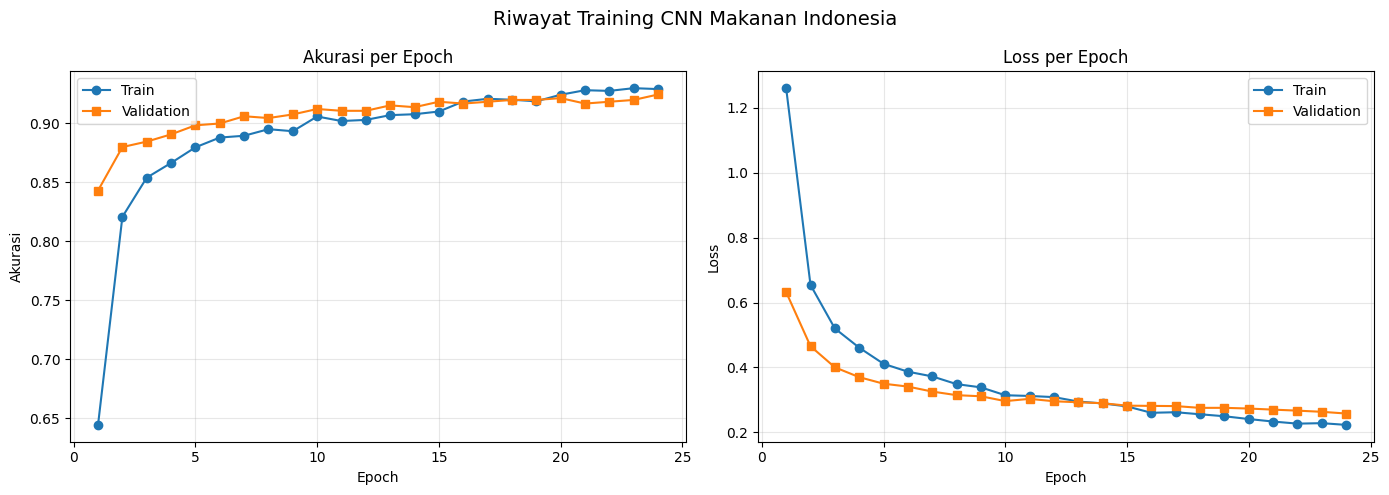

In [20]:
# ============================================================
# 12. KURVA AKURASI & LOSS TRAINING
# ============================================================

epochs_range = range(1, len(history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafik akurasi --------------------------------------------
ax1.plot(epochs_range, history['accuracy'],     'o-', label='Train')
ax1.plot(epochs_range, history['val_accuracy'], 's-', label='Validation')
ax1.set_title('Akurasi per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Akurasi')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Grafik loss ------------------------------------------------
ax2.plot(epochs_range, history['loss'],     'o-', label='Train')
ax2.plot(epochs_range, history['val_loss'], 's-', label='Validation')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Riwayat Training CNN Makanan Indonesia', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'kurva_training.png', dpi=150)
plt.show()

## 13. Evaluasi Model pada Data Test

Sel ini mengukur performa akhir model pada data **test** (data yang tidak pernah
dilihat saat training):

1. **Akurasi & loss test** secara keseluruhan.
2. **Classification report** — precision, recall, dan F1-score per kelas, untuk
   melihat kelas mana yang paling sulit dikenali.
3. **Confusion matrix** — memvisualisasikan pola kesalahan: kelas apa sering
   tertukar dengan kelas apa. Disimpan ke `outputs/confusion_matrix.png`.

Akurasi test : 0.9400
Loss test    : 0.1735

=== Classification Report ===
              precision    recall  f1-score   support

 Ayam Goreng     0.8246    0.9400    0.8785        50
      Burger     1.0000    1.0000    1.0000        50
French Fries     1.0000    1.0000    1.0000        50
   Gado-Gado     0.9038    0.9400    0.9216        50
 Ikan Goreng     0.9792    0.9400    0.9592        50
  Mie Goreng     0.9400    0.9400    0.9400        50
 Nasi Goreng     0.9556    0.8600    0.9053        50
 Nasi Padang     0.9333    0.8400    0.8842        50
       Pizza     0.9804    1.0000    0.9901        50
       Rawon     0.9787    0.9200    0.9485        50
     Rendang     0.9375    0.9000    0.9184        50
        Sate     0.9038    0.9400    0.9216        50
        Soto     0.9091    1.0000    0.9524        50

    accuracy                         0.9400       650
   macro avg     0.9420    0.9400    0.9400       650
weighted avg     0.9420    0.9400    0.9400       650



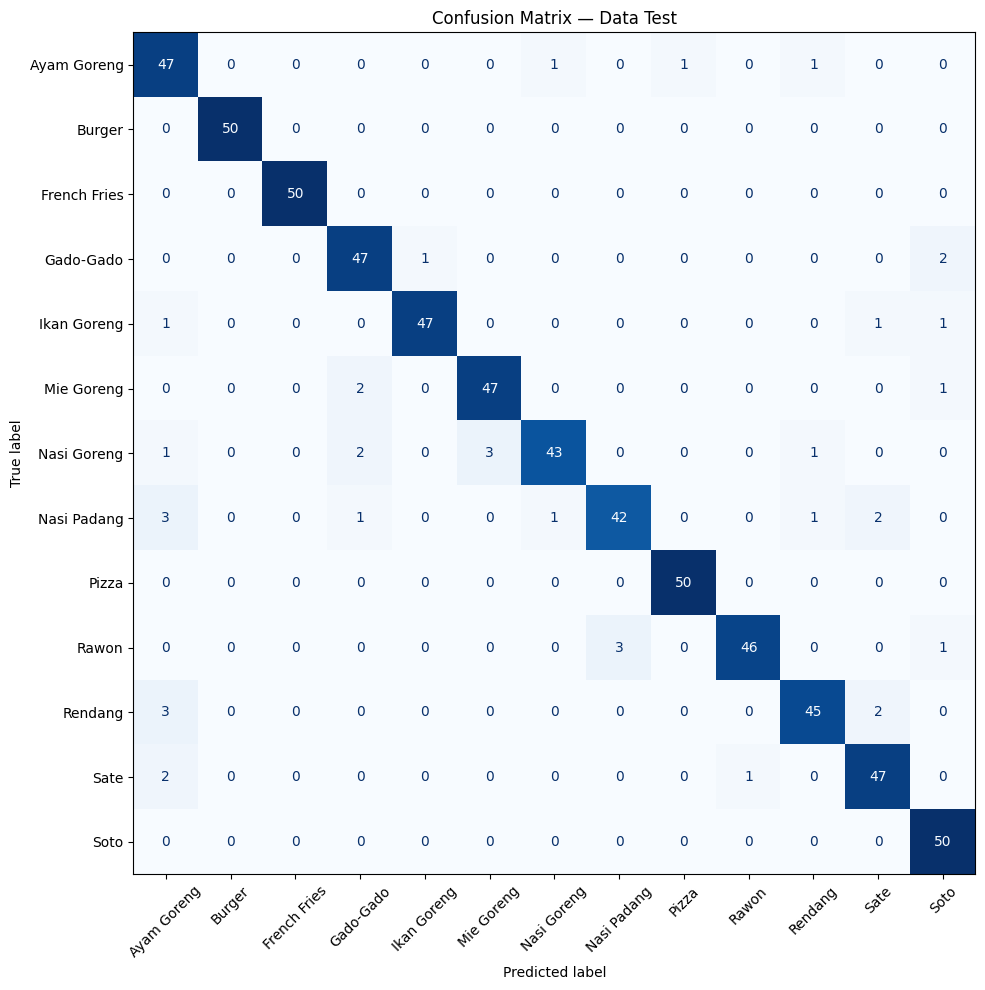

In [13]:
# ============================================================
# 13. EVALUASI: AKURASI TEST, CLASSIFICATION REPORT, CONFUSION MATRIX
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- 1) Akurasi & loss keseluruhan pada data test ---------------
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Akurasi test : {test_acc:.4f}')
print(f'Loss test    : {test_loss:.4f}\n')

# --- 2) Kumpulkan label asli & prediksi dari seluruh batch test --
y_true, y_pred = [], []
for batch_gambar, batch_label in test_ds:
    probabilitas = model.predict(batch_gambar, verbose=0)
    y_true.extend(batch_label.numpy())
    y_pred.extend(np.argmax(probabilitas, axis=1))  # ambil kelas dengan probabilitas tertinggi

# --- 3) Classification report per kelas --------------------------
print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# --- 4) Confusion matrix -----------------------------------------
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False
)
ax.set_title('Confusion Matrix — Data Test')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 14. Penyimpanan Model & Metadata

Sel ini menyimpan seluruh artefak yang dibutuhkan aplikasi UI deteksi ke folder `models/`:

| File | Isi |
|---|---|
| `cnn_food_indonesian_final.keras` | Model akhir (arsitektur + bobot terbaik) |
| `cnn_food_indonesian_best.keras`  | Checkpoint otomatis dari `ModelCheckpoint` |
| `class_names.json` | Urutan nama kelas (untuk memetakan indeks prediksi → nama makanan) |
| `model_metadata.json` | Info ukuran input, akurasi test, tanggal training (dibaca aplikasi UI) |

In [14]:
# ============================================================
# 14. SIMPAN MODEL FINAL + METADATA KELAS
# ============================================================

# --- Simpan model akhir (format .keras modern) ------------------
model.save(FINAL_MODEL_PATH)

# --- Simpan daftar nama kelas (dipakai aplikasi UI) --------------
with open(CLASS_NAMES_PATH, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# --- Simpan metadata model ---------------------------------------
metadata = {
    'nama_model'      : 'EfficientNetB0_Makanan_Indonesia',
    'dataset_kaggle'  : KAGGLE_DATASET,
    'ukuran_input'    : list(IMG_SIZE),
    'jumlah_kelas'    : NUM_CLASSES,
    'nama_kelas'      : class_names,
    'akurasi_test'    : round(float(test_acc), 4),
    'loss_test'       : round(float(test_loss), 4),
    'tanggal_training': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}
with open(METADATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(' Semua artefak tersimpan di folder models/:')
for p in sorted(MODELS_DIR.iterdir()):
    ukuran_mb = p.stat().st_size / 1e6
    print(f'   {p.name:<40} ({ukuran_mb:.2f} MB)')

 Semua artefak tersimpan di folder models/:
   class_names.json                         (0.00 MB)
   cnn_food_indonesian_best.keras           (29.13 MB)
   cnn_food_indonesian_final.keras          (29.13 MB)
   cnn_food_indonesian_finetuned.keras      (29.13 MB)
   cnn_food_indonesian_head.keras           (17.26 MB)
   model_metadata.json                      (0.00 MB)


## 15. Uji Coba Inferensi pada Satu Gambar

Sel ini mendemonstrasikan cara memakai model untuk **memprediksi satu gambar**
— alur yang sama persis dengan yang dipakai aplikasi UI deteksi:

1. Muat gambar & resize ke ukuran input model (224×224).
2. Prediksi probabilitas seluruh kelas (normalisasi `1/255` sudah ada di dalam model).
3. Tampilkan **Top-3 prediksi** beserta tingkat keyakinannya.

File gambar: c:\Users\alyus\Documents\TelU\Kuliah S2 Teknik Elektro\Pembelajaran Mendalam untuk Teknik Elektro\CNN_FOOD_INDONESIAN\dataset\dataset_gambar\test\Pizza\Pizza_466.jpg



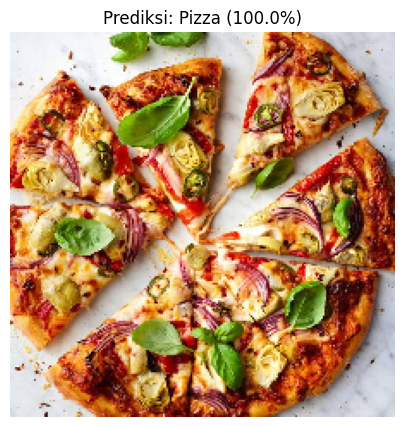

Top-3 prediksi:
  1. Pizza                      99.97%
  2. Ikan Goreng                 0.01%
  3. Gado-Gado                   0.01%


In [22]:
# ============================================================
# 15. INFERENSI: PREDIKSI SATU GAMBAR
# ============================================================

def prediksi_gambar(path_gambar, top_k=3):
    """Memprediksi kelas makanan dari satu file gambar.

    Args:
        path_gambar: path file gambar yang akan diprediksi.
        top_k: jumlah prediksi teratas yang ditampilkan.
    """
    # 1) Muat & resize gambar ke ukuran input model
    img = keras.utils.load_img(path_gambar, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)            # (224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)        # (1, 224, 224, 3) - tambah dimensi batch

    # 2) Prediksi (Rescaling 1/255 sudah ada di dalam model)
    probabilitas = model.predict(img_array, verbose=0)[0]
    urutan_top   = np.argsort(probabilitas)[::-1][:top_k]  # indeks kelas, terbesar dulu

    # 3) Tampilkan gambar + hasil prediksi
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediksi: {class_names[urutan_top[0]]} '
              f'({probabilitas[urutan_top[0]]*100:.2f}%)')
    plt.show()

    print(f'Top-{top_k} prediksi:')
    for peringkat, idx in enumerate(urutan_top, start=1):
        print(f'  {peringkat}. {class_names[idx]:<25} {probabilitas[idx]*100:6.2f}%')


# --- Demo: ambil satu gambar acak dari data test/acuan -----------
folder_demo  = struktur.get('test') or FOLDER_ACUAN
semua_gambar = [f for f in folder_demo.rglob('*') if f.suffix.lower() in IMG_EXTS]
gambar_acak  = random.choice(semua_gambar)

print(f'File gambar: {gambar_acak}\n')
prediksi_gambar(gambar_acak, top_k=3)

## 16. Penutup & Langkah Selanjutnya

 **Training selesai!** Seluruh artefak sudah tersimpan rapi:

-  `models/` — model `.keras`, `class_names.json`, dan `model_metadata.json`
-  `outputs/` — distribusi kelas, sampel gambar, kurva training, confusion matrix

### Menjalankan Aplikasi UI Deteksi

Model yang baru dilatih dapat langsung dipakai di aplikasi deteksi berbasis GUI.
Jalankan dari terminal di folder proyek:

```bash
python app/food_detector_app.py
```

Fitur aplikasi: pilih & muat model dari folder `models/`, buka gambar, deteksi dengan
Top-K probabilitas, riwayat prediksi, dan ekspor riwayat ke CSV.

### Ide Pengembangan Lebih Lanjut

- **Transfer learning** (MobileNetV2 / EfficientNet) untuk akurasi lebih tinggi dengan training lebih singkat.
- **Fine-tuning hyperparameter** — ukuran gambar, learning rate, kedalaman jaringan.
- **Class weighting / oversampling** jika distribusi kelas tidak seimbang.